![Obesity-and-Eating-Habits-header](header.png)

# Term Project Proposal
## Names: Hannah Merrill (hem2479) and Kaylee Kim (kk36778)

## 1. Project Overview

*"Obesity and Eating Habits" dataset from the UC Irvine Machine Learning Repository. The data comes from the paper 2019 "Dataset for estimation of obesity levels based on eating habits and physical condition in individuals from Colombia, Peru and Mexico," by Fabio Mendoza Palechor and Alexis De la Hoz Manotas. The dataset has estimations for the obesity levels of individuals, given eating habits and physical conditions, and contains 17 attributes and 2111 instances.*

Data Link: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

The goal of this project is to analyze and segment individuals based on their **lifestyle, dietary habits, and physical conditions** using the Obesity dataset. Rather than relying solely on traditional, predefined weight categories, this project leverages unsupervised machine learning techniques to uncover natural, hidden groupings within the population. 

Rather than relying on direct weight measurements, this project employs supervised machine learning, specifically a **Random Forest Multiclass Classifier** to determine how accurately we can categorize individuals into predefined weight classifications (ranging from Insufficient Weight to Obesity Type III) based solely on behavioral and physiological inputs. This project aims to identify which specific lifestyle factors are the strongest predictors of obesity, ultimately providing valuable insights for preventative healthcare.

## 2. Problem Statement
Obesity is a complex health issue driven by a combination of genetic, dietary, and lifestyle factors. Traditional diagnostic metrics rely heavily on direct measurements like Body Mass Index (BMI). However, understanding the underlying behavioral causes, such as physical activity, dietary choices, transportation methods, and daily technology use is crucial for early intervention. 

The core problem this project addresses is: **How accurately can a person's obesity classification be predicted without knowing their actual weight, and out of these behavioral features, which serve as the strongest predictors?**

## 3. Data Overview

<span style='background-color: rgba(138, 43, 226, 0.1); padding: 10px; display: block; border-left: 5px solid purple;'>This project leverages a **multi-dimensional dataset** that maps **Eating Habits** with **Physical Conditions** to analyze and segment health risk profiles. The key data columns utilized are as follows:

**A. Demographic & Physiological Data (Baseline Metrics)**
Core personal and physical data serving as the baseline for an individual's profile.

- `Age` **(Age)**: The continuous age of the individual. 

- `Height` & `Weight`: Continuous measurements used to establish baseline physical size and calculate traditional metrics like BMI.

- `Gender`: Categorical variable indicating the gender of the individual.

- `family_history_with_overweight` **(Genetic Disposition)**: Binary indicator of whether a family member has suffered or suffers from overweight conditions.

**B. Dietary Habits (Eating Behaviors)**
Specific self-reported dietary choices and consumption frequencies that directly impact caloric intake and nutrition.

- `FAVC` **(Frequent High-Caloric Food)**: Binary indicator of whether the individual frequently eats high-caloric food.

- `FCVC` **(Vegetable Consumption)**: Frequency of eating vegetables in main meals.

- `NCP` **(Main Meals)**: The number of main meals the individual has daily.

- `CAEC` **(Snacking Habits)**: Frequency of consuming food between main meals.

- `CH2O` **(Water Consumption)**: Daily volume of water consumed.

- `CALC` **(Alcohol Consumption)**: Frequency of alcohol consumption.

**C. Target Variable (Weight Classification)**
The primary target or label representing the current physiological outcome, which we will use to profile our unsupervised clusters.

- `NObeyesdad` **(Obesity Level)**: The categorical weight classification (ranging from Insufficient Weight to Obesity Type III). While our model relies on unsupervised clustering, this variable helps us validate and profile the resulting segments.

**D. Contextual Features (Lifestyle Factors)**
External lifestyle and behavioral factors influencing energy expenditure and metabolic health, used to map the complete behavioral profile.

- `FAF` **(Physical Activity Frequency)**: Frequency of physical activity or exercise per week. A key indicator of active energy expenditure.

- `TUE` **(Technology Use Time)**: Time spent using technological devices daily. Serves as a primary marker for sedentary behavior.

- `MTRANS` **(Transportation Mode)**: The primary mode of transportation used (e.g., Automobile, Motorbike, Bike, Public Transportation, Walking). Used to analyze the impact of passive vs. active daily routines.

- `SMOKE` **(Smoking Habit)**: Binary indicator of whether the individual smokes.

- `SCC` **(Caloric Monitoring)**: Indicates whether the individual monitors their daily caloric intake.
</span>

## 4. Data Preprocessing & Feature Engineering

In [12]:
# Importing necessary libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

In [13]:
# Load the dataset
df = pd.read_csv('ObesityDataSet.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [14]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


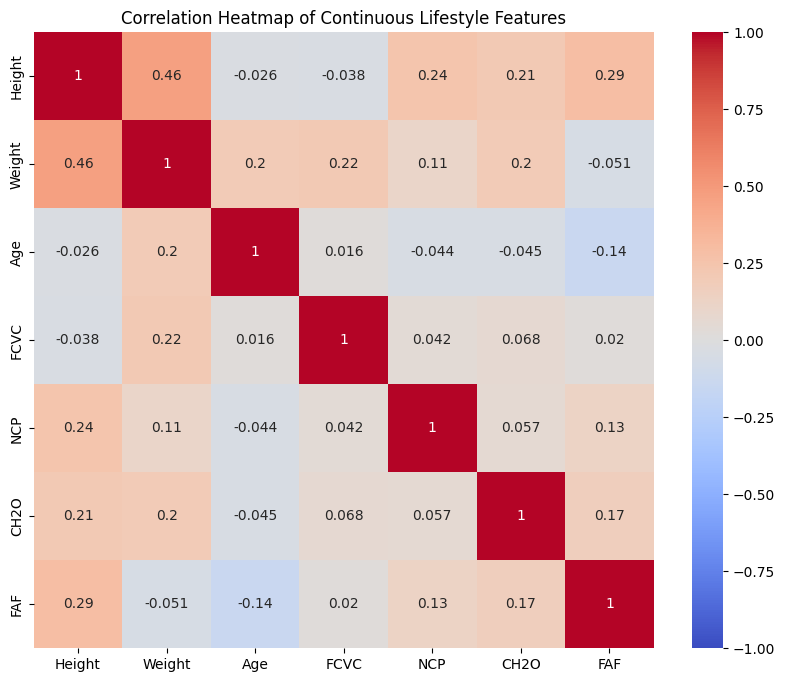

In [15]:
# Quick Data overview for numerical variables - Heat Map
numeric_cols = ['Height', 'Weight', 'Age', 'FCVC', 'NCP', 'CH2O', 'FAF']
numeric_df = df[numeric_cols]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Continuous Lifestyle Features')
plt.show()

Taking a quick look at the correlation heatmap, we can realize that there are more variables that have the possibility to play into the Obesity Levels.

# Cleaning and Encoding Dataset

In [16]:
# Converting categorical variables to dummy variables
target_column = 'NObeyesdad'
X = df.drop(columns=[target_column, 'Weight', 'Height'])  # Exclude target and original weight/height as they factor into BMI
y = df[target_column]
X_encoded = pd.get_dummies(X)
print(X_encoded.head())
print(y.head())

# Encoding the obesity categories in 'NObeyesdad'
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())

    Age  FCVC  NCP  CH2O  FAF  TUE  Gender_Female  Gender_Male  \
0  21.0   2.0  3.0   2.0  0.0  1.0           True        False   
1  21.0   3.0  3.0   3.0  3.0  0.0           True        False   
2  23.0   2.0  3.0   2.0  2.0  1.0          False         True   
3  27.0   3.0  3.0   2.0  2.0  0.0          False         True   
4  22.0   2.0  1.0   2.0  0.0  0.0          False         True   

   family_history_with_overweight_no  family_history_with_overweight_yes  ...  \
0                              False                                True  ...   
1                              False                                True  ...   
2                              False                                True  ...   
3                               True                               False  ...   
4                               True                               False  ...   

   SCC_yes  CALC_Always  CALC_Frequently  CALC_Sometimes  CALC_no  \
0    False        False            False       

In [17]:
# 3. Splitting data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# Using the Random Forest Multiclass Method

In [18]:
# 4. Initializing and Training the Random Forest Method
model = RandomForestClassifier(n_estimators=100, random_state=123)
model.fit(X_train, y_train)

# 5. Predicting obesity level based on input features
y_pred = model.predict(X_test)

# Calculating and printing the accuracy, precision, recall, and F1 of the model
score = model.score(X_test, y_test)
print(f"Accuracy of Classifier is: {score:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy of Classifier is: 0.86

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.93      0.92        56
      Normal_Weight       0.70      0.77      0.73        62
     Obesity_Type_I       0.88      0.85      0.86        78
    Obesity_Type_II       0.87      0.95      0.91        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.75      0.71      0.73        56
Overweight_Level_II       0.91      0.78      0.84        50

           accuracy                           0.86       423
          macro avg       0.86      0.86      0.86       423
       weighted avg       0.86      0.86      0.86       423



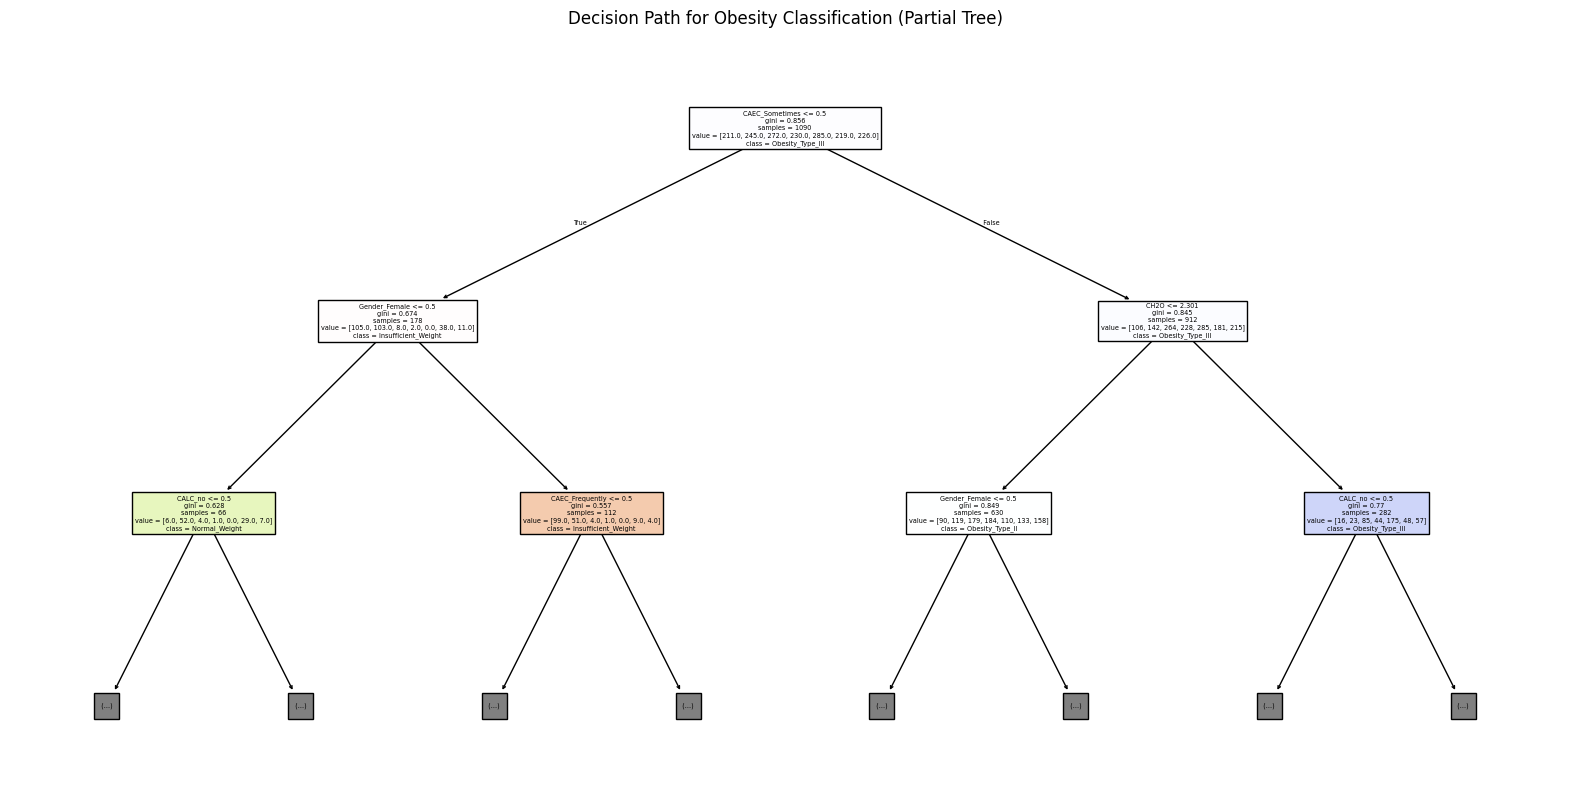

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

chosen_tree = model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(chosen_tree, feature_names=X_encoded.columns, class_names=le.classes_, filled=True, max_depth=2) 
plt.title("Decision Path for Obesity Classification (Partial Tree)")
plt.show()

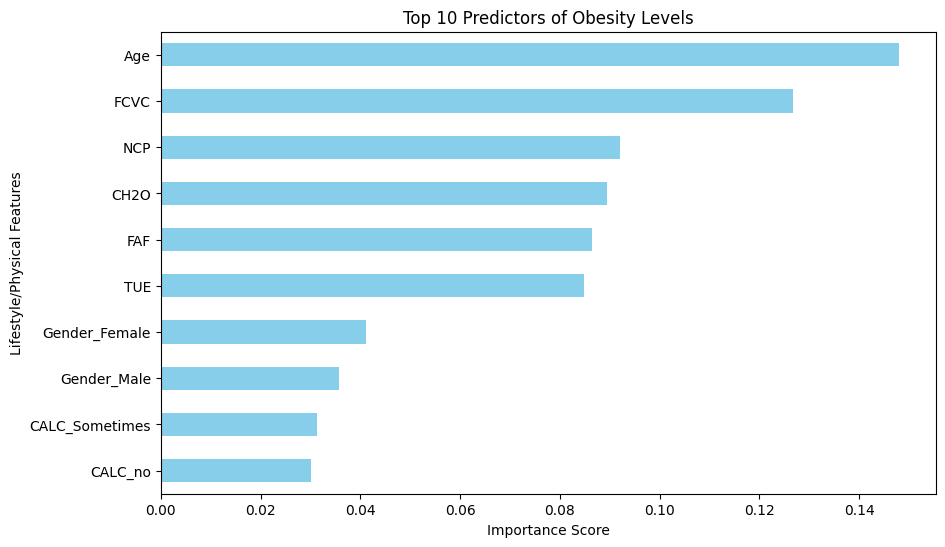

In [20]:
# Calculating feature importance
importances = pd.Series(model.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False).head(10) # Top 10 features

# Plotting feature importance
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title("Top 10 Predictors of Obesity Levels")
plt.xlabel("Importance Score")
plt.ylabel("Lifestyle/Physical Features")
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

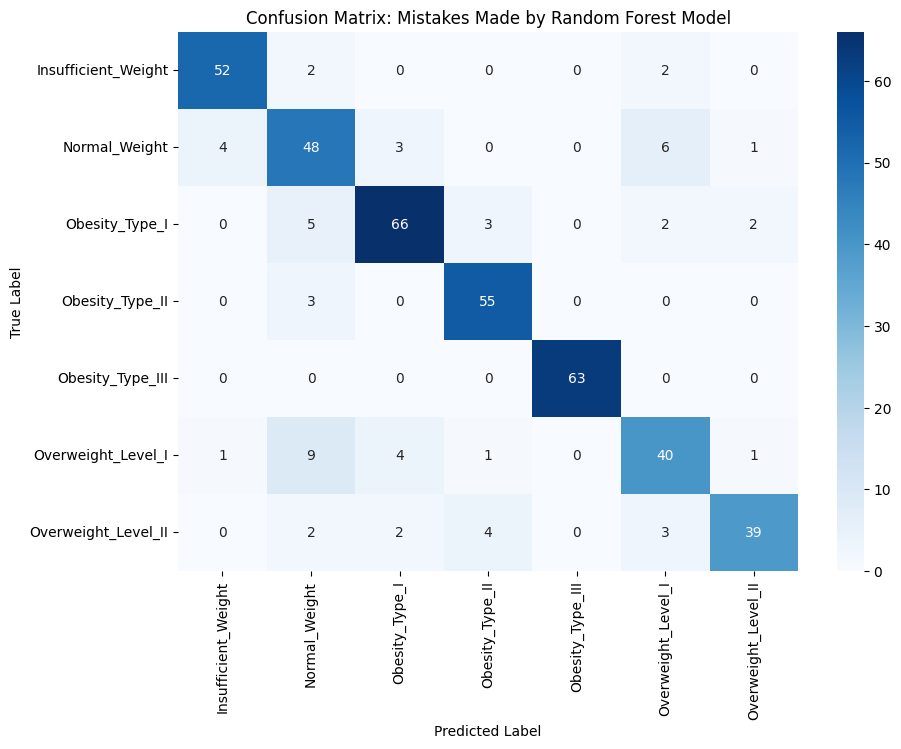

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Mistakes Made by Random Forest Model')
plt.show()